In [1]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import numpy as np
import scipy.stats as stats

# Transformations of Joint Densities

**with Thomas Lee, Vasanth Madhavan (Fall 2022)**

We develop a probability technique for finding the joint density of transformed random variables. The goal is to derive some distributions that are commonly used in statistical inference. We will start by describing how one such distribution arises.

## Review

So far we have dealt with estimation. We will now take a look at hypothesis testing, starting with a high level description of the process as we saw it in Data 8 and 100. 

Suppose data consist of a random sample. To decide between two hypotheses about the model under which the sample was generated, we create a statistic based on the sample. We then use this statistic to see which of the hypotheses is better supported by the data.

We calculate or simulate the distribution of the statistic under one of the hypotheses (called the null hypothesis). This distribution is called the null distribution of the statistic. We then compare this distribution and the observed value of the statistic. 

If the observed statistic is "too far in the tails" of the null distribution, that's evidence against the null. If the observed statistic is in the main body of the null distribution, then the data are compatible with the null hypothesis.

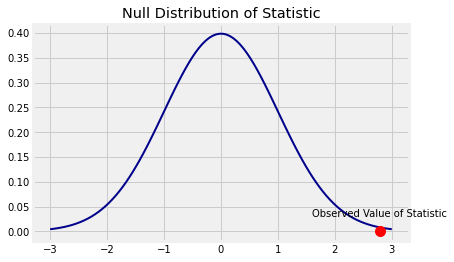

In [28]:
x = np.linspace(-3, 3, 100)
plt.plot(x, stats.norm.pdf(x, 0, 1), color='darkblue', lw=2)
plt.title('Null Distribution of Statistic')
plt.plot(2.8, 0, 'ro', ms = 10)
plt.annotate('Observed Value of Statistic', xy = (1.6, 0.03))
plt.show()

Judgment is involved in deciding whether the statistic is "too far" from what's expected under the null. Recall the [Data 8](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#historical-note-on-the-conventions) discussion about how the conventions arose.

There are two kinds of errors that we may make:
* If the null is true, the test may select the alternative. We control for this error by setting a P-value cutoff, often 0.05 or 0.01. As you know, Fisher used these values as examples. You are free to use other cutoffs. Just be clear about what you are doing.
* If the alternative is true, the test may select the null. In Data 8/100 we spend no time on this. We'll soon see that the basis for some of our standard tests involves this error as well.

There are many kinds of tests. Here are some observations about the $t$-test, developed by [William Gosset](https://en.wikipedia.org/wiki/William_Sealy_Gosset).

### $t$ Statistic ###
Suppose $X_1, X_2, ..., X_n$ are i.i.d normal $(\mu, \sigma^2)$, and let $S^2 = \frac{1}{n-1} \sum_{i=1}^n (X_i - \bar{X}_n)^2$ be the *sample variance* we defined in an earlier worksheet.

The distribution of $\frac{\bar{X}_n - \mu}{S/\sqrt{n}}$ is called the $t_{n-1}$ distribution. In standard terminology, this is the $t$ distribution with $n-1$ *degrees of freedom*. 

The statistic $\frac{\bar{X}_n - \mu}{S/\sqrt{n}}$ is called a $t$-statistic.

The worksheet will take you through a derivation of the $t$ densities. You will also check that $t_1$ is our old friend the Cauchy.

### Comparison with Standard Normal 

Remember that we are working under *the big assumption that we have an i.i.d. normal sample*. Therefore, for every $n$, the *standardized sample mean* $\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}}$ has the standard normal distribution.

The $t$-statistic simply replaces $\sigma$ by $S$ in the standardized sample mean. We know that for large $n$, $S$ is close to $\sigma$ with high probability. So it is no surprise that for large $n$, the $t_n$ density is hard to distinguish from normal $(0, 1)$.

Moreover, if $n$ is large then the assumption of underlying normality is unnecessary. Recall that in an earlier worksheet we showed that as long as the sample is i.i.d. (not necessarily normal), $\frac{\bar{X_n} - \mu}{S/\sqrt{n}}$ converges to standard normal in distribution.

But for small $n$, the $t_n$ distribution is useful provided we believe the "i.i.d. normals" assumption. It has fatter tails than the standard normal distribution. This should make sense intuitively. With just a small amount of data, our estimation of sampling variability will not be good, and we will need more wiggle room.

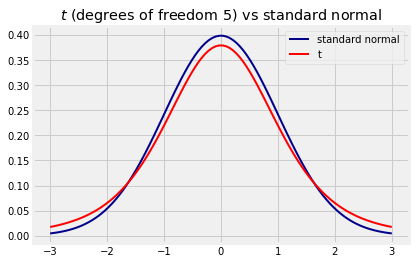

In [3]:
# change this variable to see how 
# the t distribution changes with the number of degrees of freedom
t_degrees_of_freedom = 5

x = np.linspace(-3, 3, 100)
plt.plot(x, stats.norm.pdf(x, 0, 1), color='darkblue', lw = 2, label = "standard normal")
plt.plot(x, stats.t.pdf(x, t_degrees_of_freedom), color='red', lw=2, label = "t")
plt.legend()
plt.title('$t$ (degrees of freedom '+str(t_degrees_of_freedom)+') vs standard normal');

The seminar session is devoted to developing a technique that will allow us to derive distributions like the $t$ and the $F$ which is also much used in inference.

## Change of Variable for Joint Densities

Recall from [Data 140](http://prob140.org/textbook/content/Chapter_16/02_Monotone_Functions.html#change-of-variable-formula-for-density-monotone-function) how we used change of variable to find the density of transformations of single random variable: 

Let $X$ be a random variable with density $f_X$ and $U=g(X)$ where $g(x)$ is some differentiable, monotone function.

The density $f_U$ is then: 
$$f_U(u)=\frac{f_X(x)}{|\frac{d}{dx}g(x)|} \quad \text{at} \quad x=g^{-1}(u)$$
or equivalently
$$f_U(u)=f_X(g^{-1}(u))⋅\left|\frac{d}{dx}g^{-1}(u)\right|$$

In Data 140, we also worked with densities of some functions of two random variables. For example, suppose we have random variables $X$ and $Y$ with joint density $f_{X,Y}$. We found the density $f_S$ of the sum $S=X+Y$ by calculating:
$$f_S(s)= \int_{-∞}^ {∞}f_{X,Y}(x, s-x) \enspace dx$$
since $Y$ can be put in terms of $X$ with $Y=S-X$. 

However, the analogous calculation doesn't always work for other functions of $X$ and $Y$. For example, if our function were instead a ratio $\displaystyle{R=\frac{Y}{X}}$, then we can use $Y = RX$ to make an attempt at the density of $R$. But unfortunately
$$
f_R(r) \stackrel{???}{=} \int_{-∞}^ {∞}f_{X,Y}(x, rx) \enspace dx
$$
...is not true.  

The reason for the difference is not obvious at first glance. However, if we compare the region $S \in ds$ with the region $R \in dr$, we get the diagrams below.

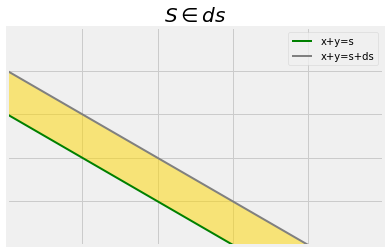

In [76]:
s, ds = 0.6, 0.2 # Arbitrary for visualization purposes
fig, ax = plt.subplots()
x = np.linspace(-1, 2, 10)
ax.plot(x, s-x, color='green', lw=2)
ax.plot(x, s+ds-x, color='grey', lw=2)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticklabels([]) # Remove axis labels for confusion
ax.set_yticklabels([])
ax.fill_between(x, s-x, s+ds-x, color='gold', alpha=0.5)
plt.legend(['x+y=s', 'x+y=s+ds'], loc="best")
plt.title('$S \in ds$', fontsize=20);



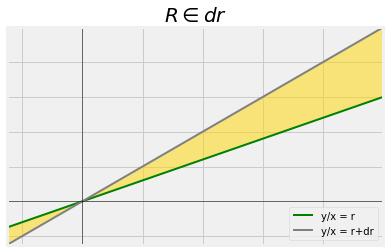

In [77]:
r, dr = 0.6, 0.4 # Arbitrary for visualization purposes
fig, ax = plt.subplots()
x = np.linspace(-1, 2, 10)
ax.plot(x, r*x, color='green', lw=2)
ax.plot(x, (r+dr)*x, color='grey', lw=2)
ax.set_xlim(-0.25, 1)
ax.set_ylim(-0.25, 1)
ax.axhline(y=0, color='k', lw=0.5)
ax.axvline(x=0, color='k', lw=0.5)
ax.set_xticklabels([]) # Remove axis labels for confusion
ax.set_yticklabels([])
ax.fill_between(x, r*x, (r+dr)*x, color='gold', alpha=0.5)
plt.legend(['y/x = r', 'y/x = r+dr'], loc="best")
plt.title('$R \in dr$', fontsize=20);

As we can observe from the above graphs, our formula for the density of the sum $S$ works because the width of the interval is always $ds$ because the slopes of both lines are the same. However, the graph of the ratio $R$ has different slopes for the two lines. The width flares as $x$ goes away from 0. This is bad because the probability is no longer dependent only on the width $dr$ (like $ds$ is in the sum) but also on $x$. Our calculation has to take that into account.

Fortunately for us, we can apply concepts from multivariable calculus to solve this. 

Let us first define some notation. $X$ and $Y$ once again have joint density $f_{X,Y}$. Let $g$ be any smooth, invertible function where $g:\mathbb{R}^2 → \mathbb{R}^2$. 

We will use the following notation:
$$g(X, Y)=(g_1(X,Y), g_2(X,Y))=(U,V)$$ 

Let 
\begin{align}
u&=g_1(x,y)\\
v&=g_2(x,y)
\end{align}

Assume that $g$ is invertible and let the function $g^{-1} = h = (h_1, h_2)$. Then

\begin{align}
x&=h_1(u,v)\\
y&=h_2(u,v)\\
\end{align}

Assume also that $g$ is differentiable.

The Jacobian $J$ is defined as

$$
  J =
  \left[ {\begin{array}{cc}
    \frac{d}{dx}g_1(x,y) & \frac{d}{dy}g_1(x,y) \\
    \frac{d}{dx}g_2(x,y) & \frac{d}{dy}g_2(x,y) \\
  \end{array} } \right]
$$
Its [inverse](https://en.wikipedia.org/wiki/Jacobian_matrix_and_determinant#Inverse) $K$ is equal to
$$
  K =
  \left[ {\begin{array}{cc}
    \frac{d}{du}h_1(u,v) & \frac{d}{dv}h_1(u,v) \\
    \frac{d}{du}h_2(u,v) & \frac{d}{dv}h_2(u,v) \\
  \end{array} } \right]
$$

It follows that $\det(J)=\displaystyle{\frac{1}{\det(K)}}$.

By an extension of our 1-dimensional calculation, it can be shown that the density of $(U, V)$ is given by 

$$f_{U,V}(u,v)=\frac{f_{X,Y}(x,y)}{|\det(J)|} \quad \text{at} \enspace x=h_1(u,v), y=h_2(u,v)$$

or equivalently

$$f_{U,V}(u,v) = f_{X,Y}(h_1(u,v),h_2(u,v)) \cdot |\det(K)|$$


## Examples

### 1. Density of a Sum 

Suppose we have random variables $X$ and $Y$ with joint density $f_{X,Y}$. In Data 140, we said that the density $f_S$ of the sum $S=X+Y$ can be found by the calculation
$$f_S(s)= \int_{-∞}^ {∞}f_{X,Y}(x, s-x) \enspace dx$$

Let's establish this using our two-variable change of variable formula. Consider the transformation

\begin{align}
U &= X\\
V &= X + Y
\end{align}

We will find the joint density of $(U, V)$ and use that to find the marginal density of $V$.

To do this, we have to crank the handle of the machine we developed above.

\begin{align}
u&=g_1(x,y) = x\\
v&=g_2(x,y) = x + y\\
x&=h_1(u,v) = u\\
y&=h_2(u,v) = v - u \quad \text{since} \enspace x=u\\
\end{align}
\
$$
  J =
  \left[ {\begin{array}{cc}
    \frac{d}{dx}g_1(x,y) & \frac{d}{dy}g_1(x,y) \\
    \frac{d}{dx}g_2(x,y) & \frac{d}{dy}g_2(x,y) \\
  \end{array} } \right]
  = \left[ {\begin{array}{cc}
    1 & 0 \\
    1 & 1 \\
  \end{array} } \right]
$$\
$$ |\det(J)| = 1 $$

Either $J$ or $K$ can be computed, and the corresponding equation can be used. In this case, computing either is relatively simple, but in some situations one will be easier than the other.

Our general formula is

$$f_{U,V}(u,v)=\frac{f_{X,Y}(x,y)}{|\det(J)|} \quad \text{at} \enspace x=h_1(u,v), y=h_2(u,v)$$

Hence
$$
f_{U,V}(u,v) ~ = ~ \frac{f_{X,Y}(u,v-u)}{1} ~ = ~ f_{X,Y}(u, v-u)
$$

We can now calculate the marginal density of $V$ by integrating out $U$:

$$ f_V(v)= \int_{-∞}^ {∞}f_{X,Y}(u, v -u) \enspace du $$

Remember that $V = X+Y$. The formula above is exactly the formula for the density of the sum provided in Data 140.

### 2. Joint Density of the Sum and Difference of i.i.d. Standard Normals

Let $X$ and $Y$ be i.i.d. standard normal, and let 

\begin{align}
U &= X + Y\\
V &= X - Y
\end{align}

Inverses can be found by adding or subtracting $g_1$ and $g_2$:

\begin{align}
u&=g_1(x,y) = x + y\\
v&=g_2(x,y) = x - y\\
x&=h_1(u,v) = \frac{u + v}{2}\\
y&=h_2(u,v) = \frac{u - v}{2}\\
\end{align}
\
$$
  J =
 \left[ {\begin{array}{cc}
    1 & 1 \\
    1 & -1 \\
  \end{array} } \right]
$$\
$$ |\det(J)| = 2 $$

We now have all the ingredients we need to plug into the change of variable formula. 

Recall the formula for density of a standard normal random variable: $f(x) = \frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}x^2}$. Since $X$ and $Y$ are independent, we can use this density to get the joint density $f_{X,Y}$, to get: 

\begin{align}
f_{U,V}(u,v) &= ~ \frac{f_{X,Y}(\frac{u + v}{2},\frac{u - v}{2})}{2} \\
&= ~ \frac{1}{2}\cdot\frac{1}{2\pi}\exp\left(-\frac{1}{2}\left(\left(\frac{u + v}{2}\right)^2 + \left(\frac{u - v}{2}\right)^2\right)\right) \\
&= ~ \frac{1}{4\pi}\exp\left(-\frac{1}{2}\left(\frac{u^2}{2} + \frac{v^2}{2}\right)\right) \\
&= ~ \frac{1}{4\pi} \exp\left(-\frac{1}{2} \cdot \frac{u^2}{2}) \cdot \exp(-\frac{1}{2} \cdot \frac{v^2}{2}\right)
\end{align}

The joint density has factored, so $U$ and $V$ are independent. Examine each factor to see that each of $U$ and $V$ is normal.

The parameters of the normals are just the means and variances, which we know are $0$ and $2$ respectively by properties of expecation and variance.

Thus $U$ and $V$ independent normal $(0, 2)$ variables.

Do you need to check that $\displaystyle{\frac{1}{4\pi}}$ is the right constant? No, because $f_{U,V}$ is a joint density and hence *must* have the right constant factor. But you can check if you wish.

In Data 140 we proved that the sum and difference of two independent standard normal random variables were independent normal variables. But that process involved MGFs to show that the sum and difference are normal, and the multivariate normal density to establish independence. The change of variable formula allows us to find the joint density of the sum and difference without using any of that heavy machinery.

### 3. Beta-Gamma Algebra

Let $X$ have the gamma $(r, \lambda)$ distribution and let $Y$ be gamma $(s, \lambda )$ independent of $X$. Define the transformed variables $U$ and $V$ as follows.

\begin{align}
U &= X + Y\\
V &=\frac{X}{X + Y}
\end{align}

$U$ is the sum and $V$ is $X$ as a proportion of the sum.

Inverses can be found by multiplying $g_1$ and $g_2$ together.

\begin{align}
u&=g_1(x,y) = x + y\\
v&=g_2(x,y) = \frac{x} {x + y}\\
x&=h_1(u,v) = uv\\
y&=h_2(u,v) = u - uv = u(1-v)
\end{align}

To avoid differentiating a quotient, we will use $K$ here.

$$
K =
  \left[ {\begin{array}{cc}
    \frac{d}{du}h_1(u,v) & \frac{d}{dv}h_1(u,v) \\
    \frac{d}{du}h_2(u,v) & \frac{d}{dv}h_2(u,v) \\
  \end{array} } \right]
  = 
 \left[ {\begin{array}{cc}
    v & u \\
    1 -v & -u \\
  \end{array} } \right]
$$

So
$$
|\det(K)| = |-uv -u(1 - v)| = |-u| = u
$$

because $u > 0$.

Now plug into the change of variable formula. Recall the density of a $X$: $f_X(x) = \frac{\lambda^r}{\Gamma(r)}x^{r - 1}e^{-\lambda x}$ for $x > 0$.

\begin{align}
f_{U,V}(u,v) &= f_{X,Y}(h_1(u,v),h_2(u,v)) \cdot |\det(K)|\\
&= f_{X,Y}(uv,u(1-v)) \cdot u
\end{align}

Since $X$ and $Y$ are independent we can write their joint density as a product.

\begin{align}
f_{U,V}(u,v) &= u \cdot \frac{\lambda^r}{\Gamma(r)}(uv)^{r - 1}e^{-\lambda uv} \cdot \frac{\lambda^s}{\Gamma(s)}(u(1 - v))^{s - 1}e^{-\lambda u(1 - v)} \\
&=u \cdot \frac{\lambda^r}{\Gamma(r)}(uv)^{r - 1}e^{-\lambda uv} \cdot \frac{\lambda^s}{\Gamma(s)}(u(1 - v))^{s - 1}e^{-\lambda u(1 - v)}\\
&=\frac{\lambda^{r+s}}{\Gamma(r+s)}u^{r +s- 1}e^{-\lambda u} \cdot \frac{\Gamma(r + s)}{\Gamma(r)\Gamma(s)}v^{r - 1}(1 - v)^{s - 1}\\
&=f_{U}(u) \cdot f_{V}(v)
\end{align} 

We have derived the following result:

### Beta-Gamma Algebra 

Let $X$ have the gamma $(r, \lambda)$ distribution and let $Y$ be gamma $(s, \lambda )$ independent of $X$. 

Let $U = X+Y$ and $V = \displaystyle{\frac{X}{X+Y}}$. Then

- $U$ is gamma $(r + s, \lambda)$
- $V$ is beta $(r, s)$.
- $U$ and $V$ are independent.

We already knew that $X+Y$ is gamma. We showed that in Data 140 using the mgf. We now know the ratio $X/(X+Y)$ is a beta independent of the sum.

### Gamma Stick Breaking

In the worksheet you will use beta-gamma algebra to establish the $F$ and $t$ distributions. Here we will ust it to "recreate" the arrival times in a Poisson process, as follows.

Suppose we have arrivals in a Poisson process specificed by an exponential ($\lambda$) or equivalently a gamma ($1, \lambda$) distribution. As we know, the time of the second arrival has the gamma ($2, \lambda$) distribution.

Now let $S$ have the gamma $(2, \lambda)$ distribution.

Let $R$ have the beta $(1, 1)$ distribution, or equivalently the uniform $(0,1)$ distribution, independent of $S$.

Let $X = RS$ and $Y = (1-R)S$. Then the beta-gamma algebra implies that $X$ and $Y$ are i.i.d. gamma $(1, \lambda)$. That is, if you start with the time to the second arrival in a Poisson process, you can multiply it by an independent beta $(1, 1)$ proportion to split it into two i.i.d. exponential $(\lambda)$ pieces. This essentially recreates the inter-arrival times.

In [49]:
s = stats.gamma.rvs(a=2)
r = stats.beta.rvs(1, 1)
s, r*s

(4.0691576831374965, 1.3385684299986569)

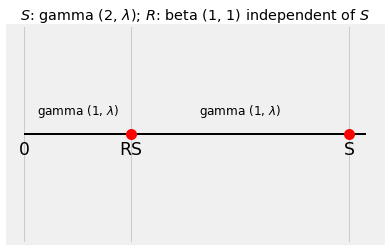

In [75]:
plt.plot([0, s+0.21], [0, 0], color='k', lw=2)
plt.plot(r*s, 0, 'ro', ms = 10)
plt.plot(s, 0, 'ro', ms = 10)
plt.text(0, -0.01, '0', size = 'xx-large', horizontalalignment = 'center')
plt.text(r*s, -0.01, 'RS', size = 'xx-large', horizontalalignment = 'center')
plt.text(s, -0.01, 'S', size = 'xx-large', horizontalalignment = 'center')
plt.text(r*s/2, 0.01, 'gamma (1, $\lambda$)', size=12, horizontalalignment = 'center')
plt.text(r*s + (1-r)*s/2, 0.01, 'gamma (1, $\lambda$)', size=12, horizontalalignment = 'center')
plt.yticks([])
plt.xticks([0, r*s, s], [])
plt.title('$S$: gamma (2, $\lambda$); $R$: beta (1, 1) independent of $S$');

The name "stick breaking" comes from pictures like the one above: a stick of random gamma length has been broken into two independent gamma pieces.

If you are concerned that the result we proved starts with two sticks and joins them together, whereas in the picture above we start with one stick and split it into two, then either notice that the maps in the beta-gamma transformations are bijections, or derive the "reverse direction" fact in the next worksheet.